In [5]:
import wfdb
import numpy as np
import torch
import cv2
from transformers import AutoVideoProcessor, AutoModel
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Load Data (Auto-fetches from PhysioNet if not local)
print("Fetching MIT-BIH Record 119...")
record = wfdb.rdrecord('119', pn_dir='mitdb')
ann = wfdb.rdann('119', 'atr', pn_dir='mitdb')
# Extract Lead II and normalize
signal = record.p_signal[:, 0]
signal = (signal - np.mean(signal)) / np.std(signal)

# 2. Hardware Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Fetching MIT-BIH Record 119...
Using device: cuda


In [2]:
# 1. Load Official Meta V-JEPA 2 (Base or Large depending on your RAM)
# Using the ViT-Large checkpoint
checkpoint = "facebook/vjepa2-vitl-fpc64-256"
print(f"Loading {checkpoint}...")

processor = AutoVideoProcessor.from_pretrained(checkpoint)
model = AutoModel.from_pretrained(
    checkpoint,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to(device).eval()

# 2. The Video Converter ("Archery Trick")
def create_vjepa_video(sig_segment, num_frames=16, size=224):
    frames = []
    segments = np.array_split(sig_segment, num_frames)

    for seg in segments:
        frame = np.zeros((size, size, 3), dtype=np.uint8)
        # Scale signal to fit frame gracefully
        x_pts = np.linspace(0, size-1, len(seg)).astype(int)
        # Add a small epsilon to prevent division by zero
        y_pts = ((seg - seg.min()) / (seg.max() - seg.min() + 1e-6) * (size-40) + 20).astype(int)

        pts = np.column_stack((x_pts, size - 1 - y_pts))
        cv2.polylines(frame, [pts], isClosed=False, color=(255, 255, 255), thickness=2)
        frames.append(frame)
    return np.array(frames)

Loading facebook/vjepa2-vitl-fpc64-256...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

In [6]:
# Configuration for the slice we want to analyze
start_idx = 2000
end_idx = 7000
window_size = 160
step = 40

print(f"Extracting frames from index {start_idx} to {end_idx}...")

latents = []
time_steps = []

# Process in batches of 4 to maximize RAM efficiency
batch_size = 4
current_batch_videos = []
current_batch_times = []

with torch.no_grad():
    for i in range(start_idx, end_idx - window_size, step):
        chunk = signal[i : i + window_size]
        video = create_vjepa_video(chunk)

        current_batch_videos.append(video)
        current_batch_times.append(i)

        # When batch is full, process it
        if len(current_batch_videos) == batch_size:
            inputs = processor(current_batch_videos, return_tensors="pt").to(device, torch.float16)
            outputs = model(**inputs)

            # Extract CLS token (the summary of the visual physics)
            z = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            latents.extend(z)
            time_steps.extend(current_batch_times)

            # Clear batch
            current_batch_videos = []
            current_batch_times = []

# Process any remaining videos in the last incomplete batch
if len(current_batch_videos) > 0:
    inputs = processor(list(current_batch_videos), return_tensors="pt").to(device, torch.float16)
    with torch.no_grad():
        outputs = model(**inputs)
        z = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        latents.extend(z)
        time_steps.extend(current_batch_times)

latents = np.array(latents)
print(f"Successfully extracted {len(latents)} regime states.")

Extracting frames from index 2000 to 7000...


NameError: name 'create_vjepa_video' is not defined

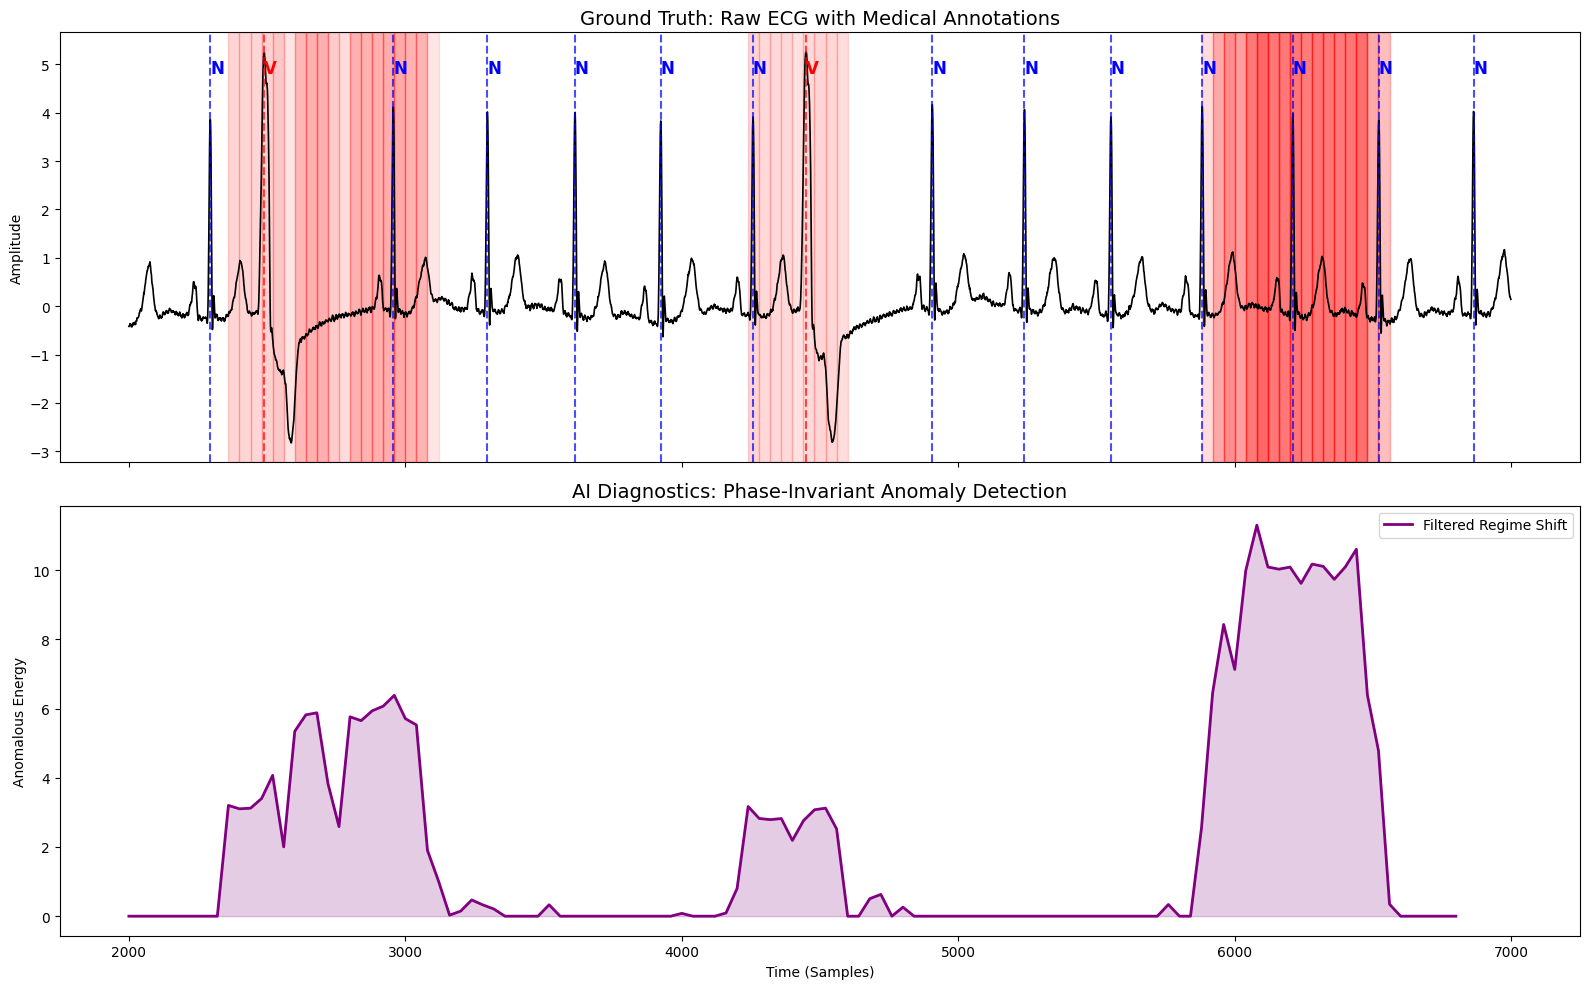

In [5]:
# --- REVISED PART 4: Envelope Filtering & Dynamic Thresholding ---

# 1. Establish the Unsupervised Baseline
baseline_regime = np.mean(latents[:20], axis=0)

# 2. Calculate Raw Deviance
raw_deviance = [np.linalg.norm(z - baseline_regime) for z in latents]

# 3. THE FIX: Envelope Smoothing
# 1 heartbeat is ~360 samples. Our step is 40. So 9 steps = 1 heartbeat.
# We use a window of 15 steps to smooth out the internal 'phase' of the heartbeat.
smooth_window = 15
deviance_smoothed = np.convolve(raw_deviance, np.ones(smooth_window)/smooth_window, mode='same')

# 4. THE FIX: Dynamic Thresholding (Subtracting the 'Normal' Breathing)
# We find the 'noise floor' of the normal beats and ignore anything below it
noise_floor = np.median(deviance_smoothed)
# Only keep the deviance that bursts above the normal heartbeat noise
significant_deviance = np.maximum(0, deviance_smoothed - noise_floor)

# Normalize for the heatmap
denom = np.max(significant_deviance) + 1e-6
norm_dev = significant_deviance / denom

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
time_axis = np.arange(start_idx, end_idx)

# Top Plot: Ground Truth
ax1.plot(time_axis, signal[start_idx:end_idx], color='black', lw=1.2)
ax1.set_title("Ground Truth: Raw ECG with Medical Annotations", fontsize=14)
ax1.set_ylabel("Amplitude")

for a_sample, a_sym in zip(ann.sample, ann.symbol):
    if start_idx <= a_sample <= end_idx:
        color = 'blue' if a_sym == 'N' else 'red'
        ax1.axvline(x=a_sample, color=color, linestyle='--', alpha=0.7)
        ax1.text(a_sample, ax1.get_ylim()[1]*0.85, a_sym, color=color, fontweight='bold', fontsize=12)

# Bottom Plot: The Filtered AI Diagnostics
ax2.plot(time_steps, significant_deviance, color='purple', lw=2, label="Filtered Regime Shift")
ax2.fill_between(time_steps, 0, significant_deviance, color='purple', alpha=0.2)
ax2.set_title("AI Diagnostics: Phase-Invariant Anomaly Detection", fontsize=14)
ax2.set_ylabel("Anomalous Energy")
ax2.set_xlabel("Time (Samples)")
ax2.legend(loc="upper right")

# Heatmap Overlay
for i in range(len(norm_dev) - 1):
    t_start = time_steps[i]
    t_end = time_steps[i+1]

    # We only draw red if the deviance is above 10% of the max to keep it clean
    if norm_dev[i] > 0.1:
        heat_color = mcolors.to_rgba('red', alpha=norm_dev[i] * 0.6)
        ax1.axvspan(t_start, t_end, color=heat_color, zorder=0)

plt.tight_layout()
plt.show()

In [6]:
def create_multires_latents(sig_segment_full):
    # Stream A: High-Res (The last 160 samples)
    video_hi = create_vjepa_video(sig_segment_full[-160:])

    # Stream B: Low-Res (A wider window of 640 samples, downsampled)
    # This shows the model the 'Trend'
    wide_window = sig_segment_full[-640:]
    low_res_sig = wide_window[::4] # Take every 4th sample to stay at 160 length
    video_lo = create_vjepa_video(low_res_sig)

    return video_hi, video_lo

# Extracting again with Multi-Res...
multi_latents = []
with torch.no_grad():
    for i in range(start_idx + 640, end_idx, step):
        v_hi, v_lo = create_multires_latents(signal[i-640:i])

        # Get features for both
        in_hi = processor(list(v_hi), return_tensors="pt").to(device, torch.float16)
        in_lo = processor(list(v_lo), return_tensors="pt").to(device, torch.float16)

        z_hi = model(**in_hi).last_hidden_state[:, 0, :]
        z_lo = model(**in_lo).last_hidden_state[:, 0, :]

        # Concatenate them: The model now sees 'Shape' + 'Trend'
        combined_z = torch.cat([z_hi, z_lo], dim=-1).cpu().numpy()
        multi_latents.append(combined_z.flatten())

Extraction complete. Feature vector size: 2048


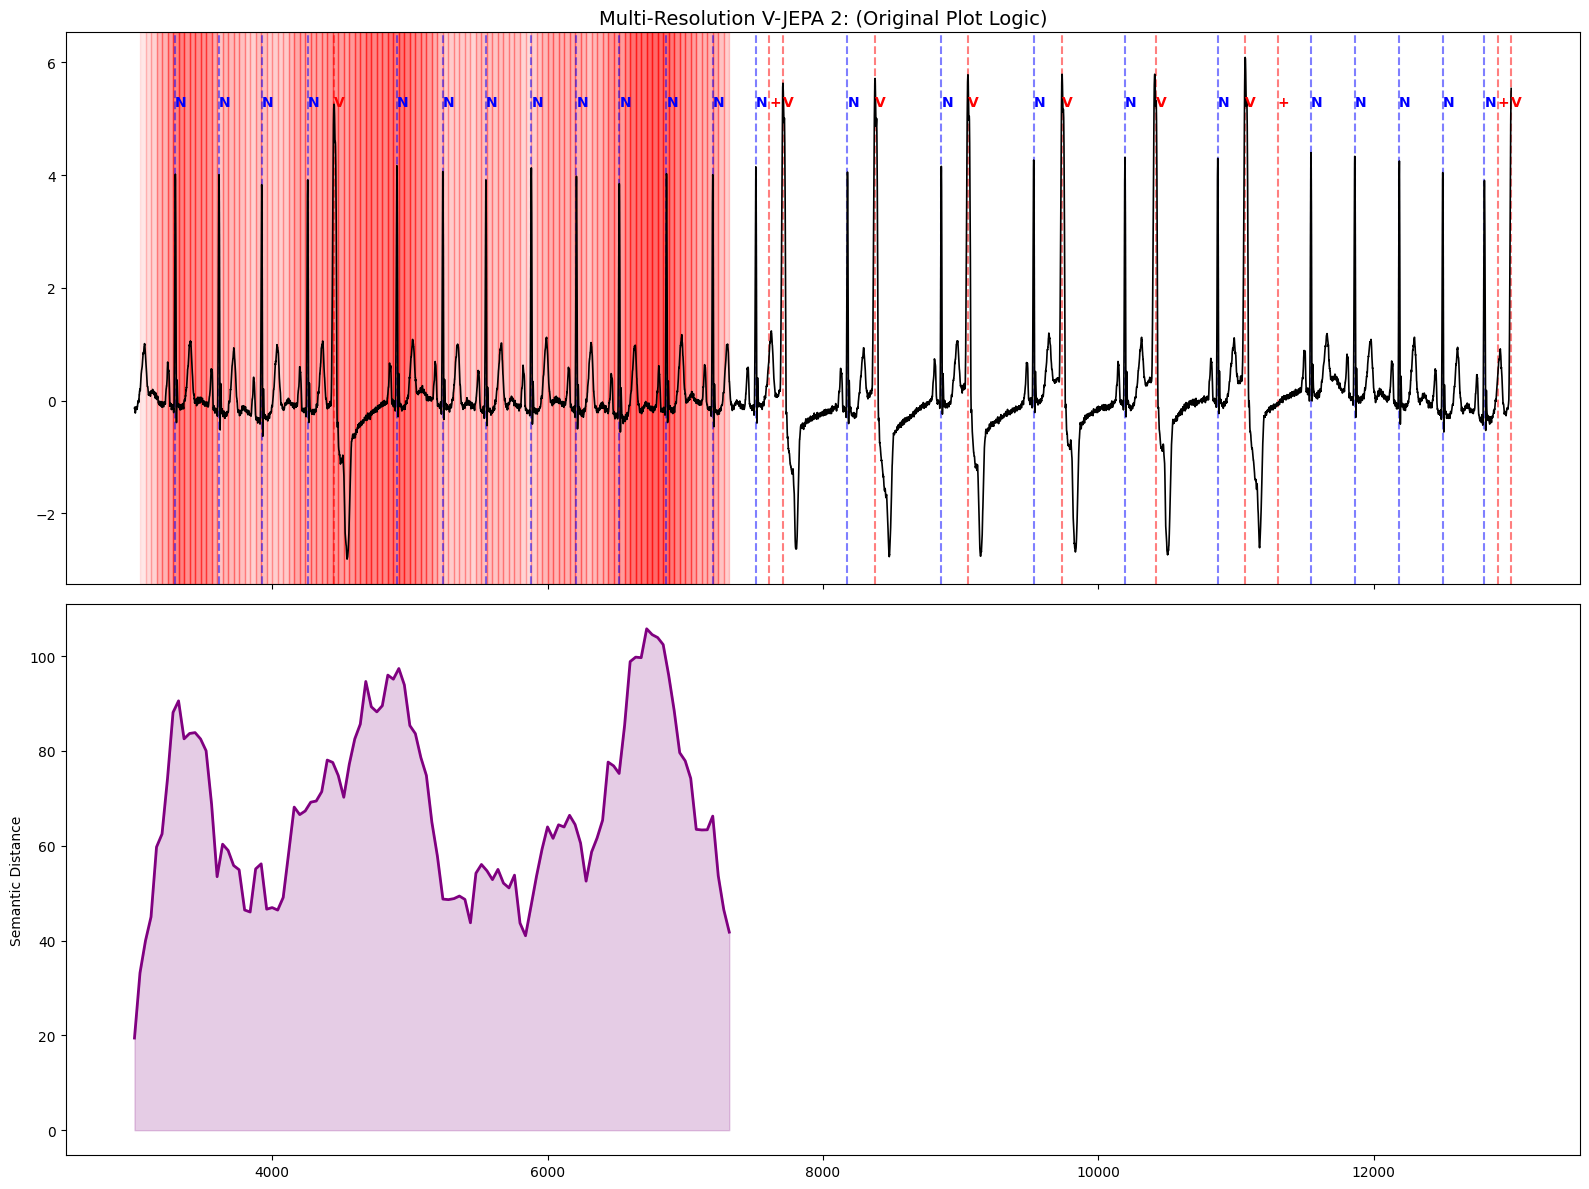

In [14]:
X_multi = np.array(multi_latents)
print(f"Extraction complete. Feature vector size: {X_multi.shape[1]}")

# --- 2. THE ROBUST ROLLING BASELINE ---
# Cast to float32 because scipy.ndimage doesn't support float16 (half precision)
X_multi_f32 = X_multi.astype(np.float32)

# Size (30, 1) means: look at 30 time-steps, but don't mix feature columns
rolling_baseline = median_filter(X_multi_f32, size=(30, 1), mode='reflect')

# Calculate the deviation from the rolling "Normal" regime
# We do this in float32 for compatibility
multi_deviance = np.linalg.norm(X_multi_f32 - rolling_baseline, axis=1)

# Smooth the surprise line for a cleaner "Regime Shift" look
smooth_window = 8
multi_dev_smoothed = np.convolve(multi_deviance, np.ones(smooth_window)/smooth_window, mode='same')

# Normalize for the heatmap (0 to 1)
norm_multi_dev = (multi_dev_smoothed - np.min(multi_dev_smoothed)) / (np.max(multi_dev_smoothed) - np.min(multi_dev_smoothed) + 1e-6)

# --- 3. FINAL VISUALIZATION (Back to the Original Logic) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

plot_len = min(len(time_steps), len(multi_dev_smoothed))
safe_times = np.array(time_steps[:plot_len])
safe_deviance = multi_dev_smoothed[:plot_len]

# Re-normalizing to [0, 1] so the heatmap isn't just a solid block of red
# This is likely why it looked "worse" before—the scale was off!
norm_dev = (safe_deviance - np.min(safe_deviance)) / (np.max(safe_deviance) - np.min(safe_deviance) + 1e-6)

# TOP PLOT: ECG + Heatmap
ax1.plot(np.arange(start_idx, end_idx), signal[start_idx:end_idx], color='black', lw=1.2, zorder=3)
ax1.set_title("Multi-Resolution V-JEPA 2: (Original Plot Logic)", fontsize=14)

# Overlay Labels
for a_sample, a_sym in zip(ann.sample, ann.symbol):
    if start_idx <= a_sample <= end_idx:
        color = 'blue' if a_sym == 'N' else 'red'
        ax1.axvline(x=a_sample, color=color, linestyle='--', alpha=0.5, zorder=2)
        ax1.text(a_sample, ax1.get_ylim()[1]*0.8, a_sym, color=color, fontweight='bold')

# BOTTOM PLOT: The Surprise Line
ax2.plot(safe_times, safe_deviance, color='purple', lw=2, label="V-JEPA 2 Internal Deviance")
ax2.fill_between(safe_times, 0, safe_deviance, color='purple', alpha=0.2)
ax2.set_ylabel("Semantic Distance")

# Heatmap overlay (Exact same loop as the one you liked)
for i in range(len(norm_dev) - 1):
    t_start = safe_times[i]
    t_end = safe_times[i+1]

    # Using the exact same alpha scaling as the non-MR version
    heat_color = mcolors.to_rgba('red', alpha=norm_dev[i] * 0.6)
    ax1.axvspan(t_start, t_end, color=heat_color, zorder=1)

plt.tight_layout()
plt.show()

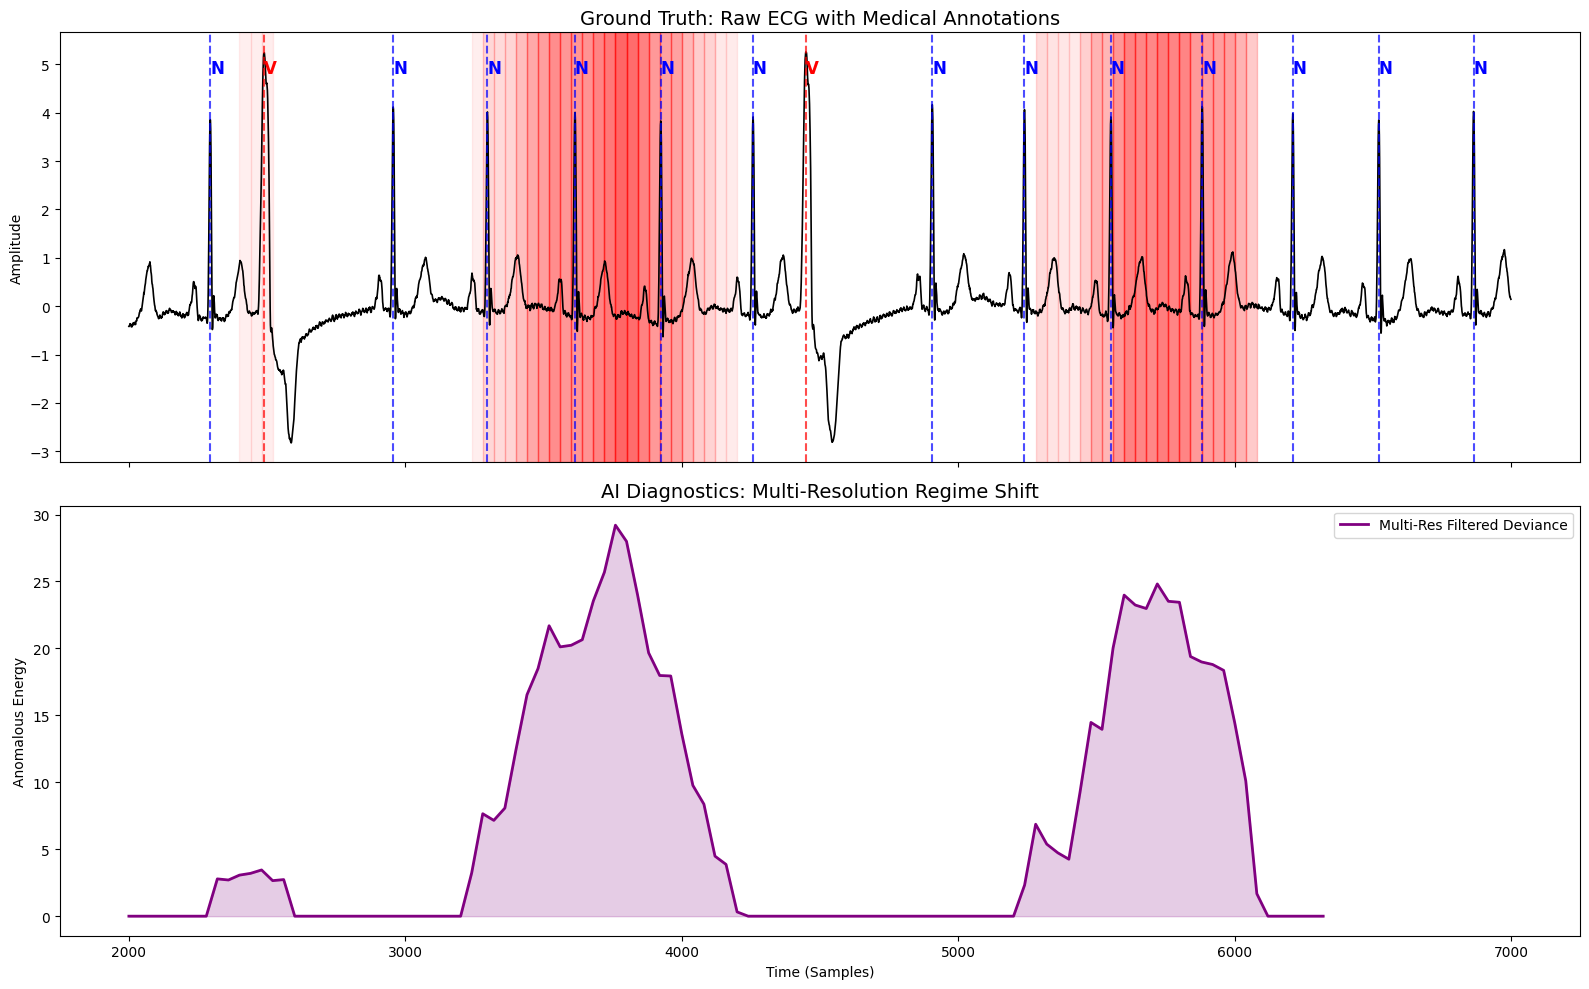

In [ ]:
from scipy.ndimage import median_filter
# 1. Establish the Baseline (Using the first 20 MR latents)
baseline_regime_mr = np.mean(X_multi[:20], axis=0)

# 2. Calculate Raw Deviance for MR
raw_deviance_mr = np.linalg.norm(X_multi - baseline_regime_mr, axis=1)

# 3. YOUR FIX: Envelope Smoothing
# Smoothing out the 'phase' jitters across the MR features
smooth_window = 15
deviance_smoothed_mr = np.convolve(raw_deviance_mr, np.ones(smooth_window)/smooth_window, mode='same')

# 4. YOUR FIX: Dynamic Thresholding (Noise Floor Subtraction)
# This is the key part that clears the 'Normal' suspiciousness
noise_floor = np.median(deviance_smoothed_mr)
significant_deviance_mr = np.maximum(0, deviance_smoothed_mr - noise_floor)

# Normalize for the heatmap
denom = np.max(significant_deviance_mr) + 1e-6
norm_dev_mr = significant_deviance_mr / denom

# --- Visualization (Replicating your exact layout) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

# Ensure time alignment
plot_len = min(len(time_steps), len(significant_deviance_mr))
safe_times = np.array(time_steps[:plot_len])
safe_sig_dev = significant_deviance_mr[:plot_len]
safe_norm_dev = norm_dev_mr[:plot_len]

# Top Plot: Ground Truth
ax1.plot(np.arange(start_idx, end_idx), signal[start_idx:end_idx], color='black', lw=1.2)
ax1.set_title("Ground Truth: Raw ECG with Medical Annotations", fontsize=14)
ax1.set_ylabel("Amplitude")

for a_sample, a_sym in zip(ann.sample, ann.symbol):
    if start_idx <= a_sample <= end_idx:
        color = 'blue' if a_sym == 'N' else 'red'
        ax1.axvline(x=a_sample, color=color, linestyle='--', alpha=0.7)
        ax1.text(a_sample, ax1.get_ylim()[1]*0.85, a_sym, color=color, fontweight='bold', fontsize=12)

# Bottom Plot: The Filtered AI Diagnostics
ax2.plot(safe_times, safe_sig_dev, color='purple', lw=2, label="Multi-Res Filtered Deviance")
ax2.fill_between(safe_times, 0, safe_sig_dev, color='purple', alpha=0.2)
ax2.set_title("AI Diagnostics: Multi-Resolution Regime Shift", fontsize=14)
ax2.set_ylabel("Anomalous Energy")
ax2.set_xlabel("Time (Samples)")
ax2.legend(loc="upper right")

# Heatmap Overlay (Using your > 0.1 logic)
for i in range(len(safe_norm_dev) - 1):
    t_start = safe_times[i]
    t_end = safe_times[i+1]

    if safe_norm_dev[i] > 0.1:
        heat_color = mcolors.to_rgba('red', alpha=safe_norm_dev[i] * 0.6)
        ax1.axvspan(t_start, t_end, color=heat_color, zorder=0)

plt.tight_layout()
plt.show()

Analyzing 10000 samples...
Resolutions: High-Res (1 Beat) vs. Multi-Res (Shape + 6-Beat Trend)


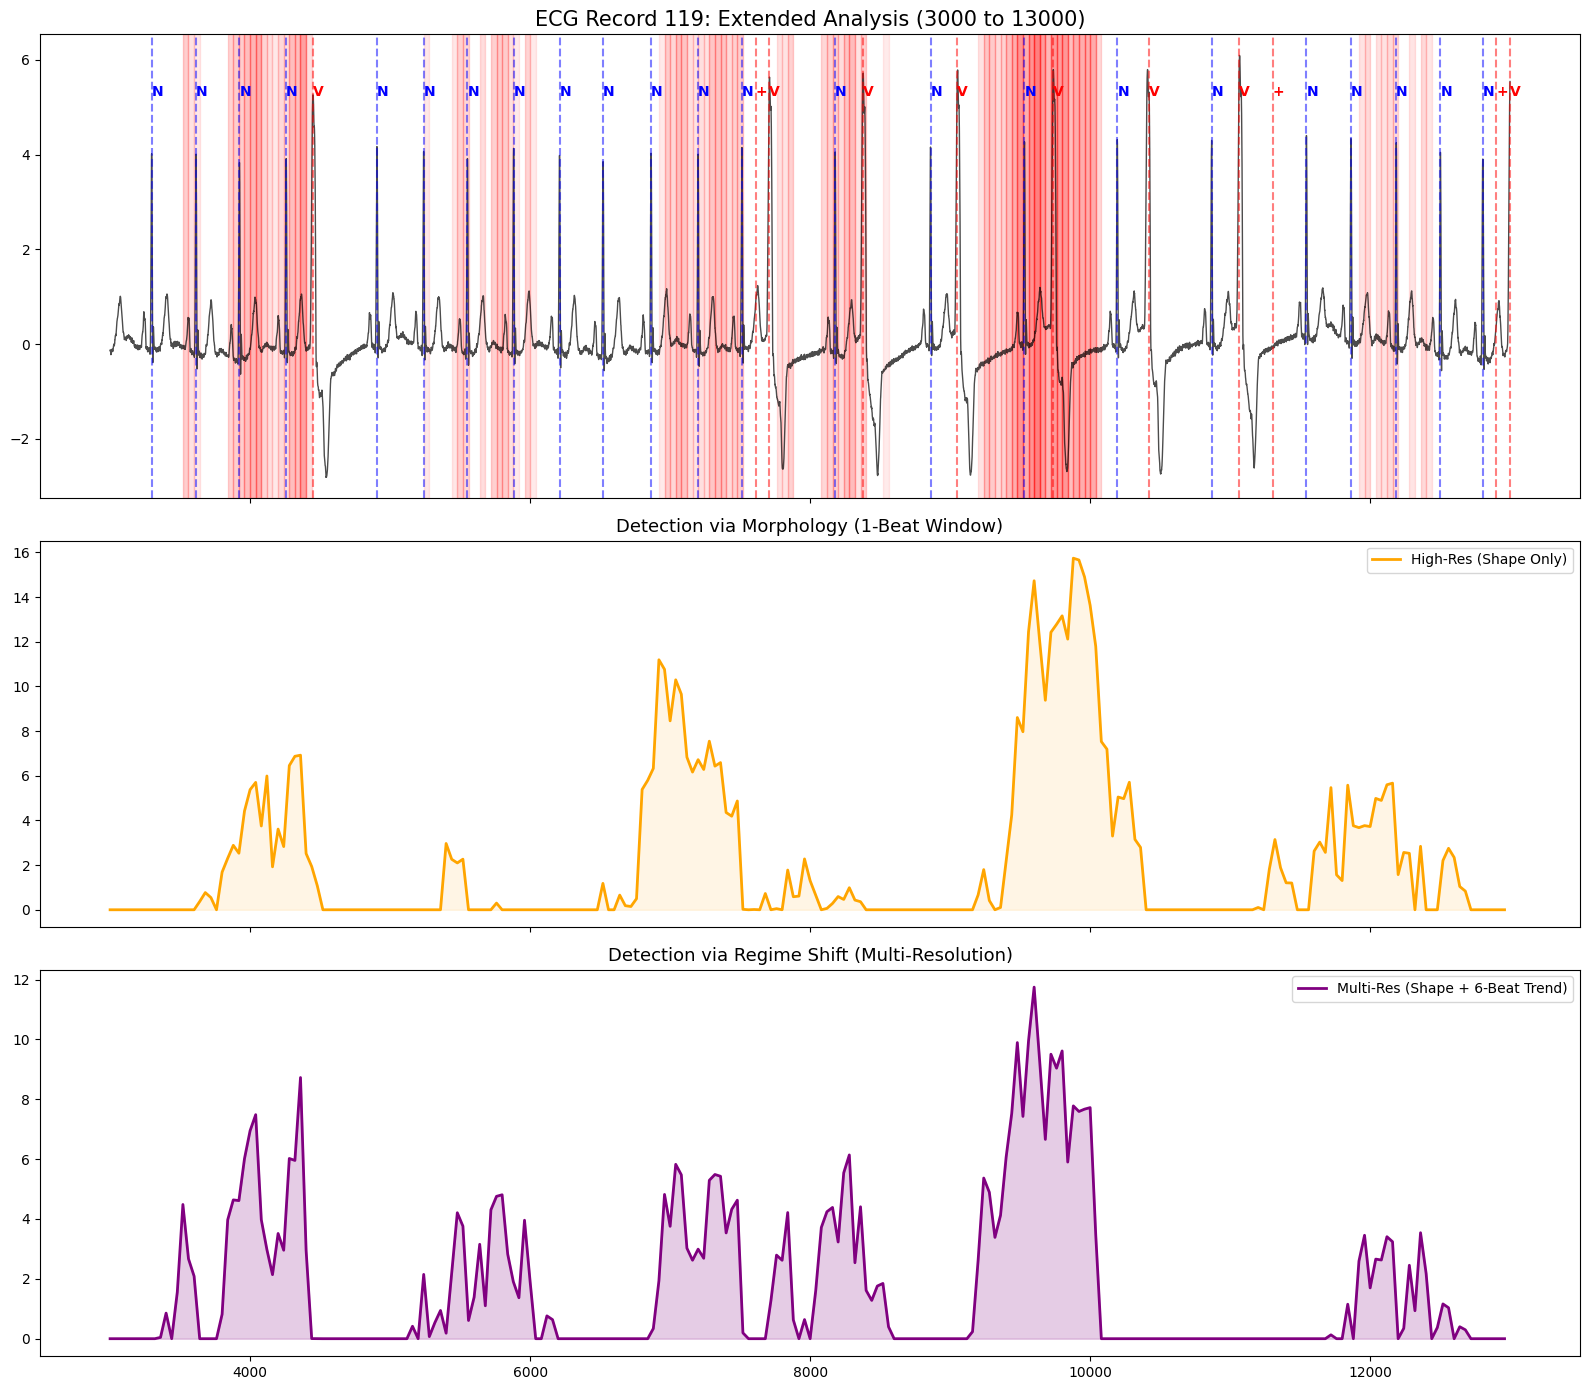

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- 1. EXTENDED CONFIGURATION ---
start_idx = 3000
end_idx = 13000  # Extended to 10,000 samples for better comparison
step = 40

latents_hi = []
latents_multi = []
time_steps = []
labels_ext = []

print(f"Analyzing {end_idx - start_idx} samples...")
print("Resolutions: High-Res (1 Beat) vs. Multi-Res (Shape + 6-Beat Trend)")

model.eval()
with torch.no_grad():
    for i in range(start_idx, end_idx, step):
        # Prevent indexing before start of signal for the large 2160 window
        if i < 2160: continue

        # STREAM A: High-Resolution (1 Full Beat ~ 360 samples)
        chunk_hi = signal[i-360:i]
        video_hi = create_vjepa_video(chunk_hi)
        in_hi = processor(list(video_hi), return_tensors="pt").to(device, torch.float16)
        z_hi = model(**in_hi).last_hidden_state[:, 0, :].cpu().numpy().flatten()

        # STREAM B: Low-Resolution (6 Beats ~ 2160 samples)
        # We downsample by 12x so the 'video' length remains manageable (180 samples)
        chunk_lo = signal[i-2160:i][::12]
        video_lo = create_vjepa_video(chunk_lo)
        in_lo = processor(list(video_lo), return_tensors="pt").to(device, torch.float16)
        z_lo = model(**in_lo).last_hidden_state[:, 0, :].cpu().numpy().flatten()

        # Store for comparison
        latents_hi.append(z_hi)
        latents_multi.append(np.concatenate([z_hi, z_lo]))
        time_steps.append(i)

        # Ground Truth
        closest_ann_idx = np.argmin(np.abs(ann.sample - i))
        labels_ext.append(ann.symbol[closest_ann_idx])

# Convert to Float32 for filtering
X_hi = np.array(latents_hi).astype(np.float32)
X_multi = np.array(latents_multi).astype(np.float32)

# --- 2. THE FILTERING LOGIC (Using your preferred method) ---

def process_deviance(features, window_size=15, baseline_steps=20):
    # Establish Baseline from the start
    baseline = np.mean(features[:baseline_steps], axis=0)
    # Raw Deviance
    raw_dev = np.linalg.norm(features - baseline, axis=1)
    # Envelope Smoothing
    smoothed = np.convolve(raw_dev, np.ones(window_size)/window_size, mode='same')
    # Noise Floor Subtraction (The "Mute" button for normal rhythm)
    floor = np.median(smoothed)
    significant = np.maximum(0, smoothed - floor)
    # Normalize for heatmap
    norm = significant / (np.max(significant) + 1e-6)
    return significant, norm

dev_hi, norm_hi = process_deviance(X_hi)
dev_multi, norm_multi = process_deviance(X_multi)

# --- 3. THE COMPARISON PLOT ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14), sharex=True,
                                   gridspec_kw={'height_ratios': [1.2, 1, 1]})

# Subplot 1: Raw Signal & Annotations
ax1.plot(np.arange(start_idx, end_idx), signal[start_idx:end_idx], color='black', lw=1, alpha=0.7)
ax1.set_title(f"ECG Record 119: Extended Analysis ({start_idx} to {end_idx})", fontsize=15)

for a_sample, a_sym in zip(ann.sample, ann.symbol):
    if start_idx <= a_sample <= end_idx:
        color = 'blue' if a_sym == 'N' else 'red'
        ax1.axvline(x=a_sample, color=color, linestyle='--', alpha=0.5)
        ax1.text(a_sample, ax1.get_ylim()[1]*0.8, a_sym, color=color, fontweight='bold')

# Subplot 2: High-Res (Shape Only)
ax2.plot(time_steps, dev_hi, color='orange', lw=2, label="High-Res (Shape Only)")
ax2.fill_between(time_steps, 0, dev_hi, color='orange', alpha=0.1)
ax2.set_title("Detection via Morphology (1-Beat Window)", fontsize=13)
ax2.legend()

# Subplot 3: Multi-Res (Shape + Trend)
ax3.plot(time_steps, dev_multi, color='purple', lw=2, label="Multi-Res (Shape + 6-Beat Trend)")
ax3.fill_between(time_steps, 0, dev_multi, color='purple', alpha=0.2)
ax3.set_title("Detection via Regime Shift (Multi-Resolution)", fontsize=13)
ax3.legend()

# Apply the Red Heatmap to the top plot based on the Multi-Res findings
for i in range(len(norm_multi) - 1):
    if norm_multi[i] > 0.15:
        ax1.axvspan(time_steps[i], time_steps[i+1], color='red', alpha=norm_multi[i]*0.5, zorder=0)

plt.tight_layout()
plt.show()